In [20]:
import numpy as np
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from DESolver import DESolver
from problems_ODEs import ProblemsODE
from problems_PDEs import ProblemsPDE

import seaborn as sns
sns.set_context("talk", font_scale=1.) # "talk"

In [21]:
solver=DESolver()
solver.set_info(0)
rhs_e, rhs_i, u_ini, problem_setup, problem = ProblemsODE('Barnes',{'p1':1.,'p2':1.,'p3':1.})
solver.setup()
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)
solver.set_method('GLEE-1BEE')

if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:} with dt {:}'.format(problem_setup['name'],solver.get_method_name(),solver._dt))
solver.solve()

t,u_glee,glee,_,_=solver.get_trajectory_GLEE()

solver.reset()
solver.set_info(0)
solver.setup()
solver.set_initial_solution(u_ini)
solver.set_method('BE')
    
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:} with dt {:}'.format(problem_setup['name'],solver.get_method_name(),solver._dt))
solver.solve();

t_be,u_be,_,_,_=solver.get_trajectory_GLEE()
print("T shape {:}; U shape {:}".format(t_be.shape,u_be.shape))


solver.reset()
solver.set_info(0)
solver.setup()
solver.set_initial_solution(u_ini)
solver.set_method('RK4')
    
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=0.1*problem_setup['DT'])
print('Solving {:} by using {:} with dt {:}'.format(problem_setup['name'],solver.get_method_name(),solver._dt))
solver.solve();

t_ref,u_ref,_,_,_=solver.get_trajectory_GLEE(t_be)
print("T shape {:}; U shape {:}".format(t_be.shape,u_be.shape))







Solving Barnes by using GLEE-1BEE with dt 0.01
Solving Barnes by using BE with dt 0.01
T shape (2001,); U shape (2, 2001)
Solving Barnes by using RK4 with dt 0.001
T shape (2001,); U shape (2, 2001)


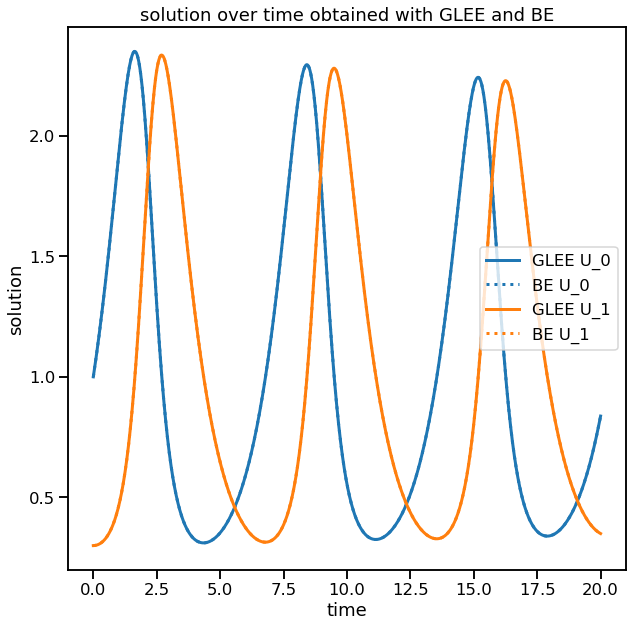

In [22]:
fig = plt.figure(figsize=(10, 10))
for i in range(u_glee.shape[0]):
    h=plt.plot(t,u_glee[i,:],'-', lw=3, label = 'GLEE U_{:}'.format(i))
    col=h[0].get_color()
    plt.plot(t,u_be[i,:],':', lw=3, color=col, label = 'BE U_{:}'.format(i))
plt.ylabel('solution')
plt.xlabel('time')
plt.legend()
plt.title('solution over time obtained with GLEE and BE')
plt.show()

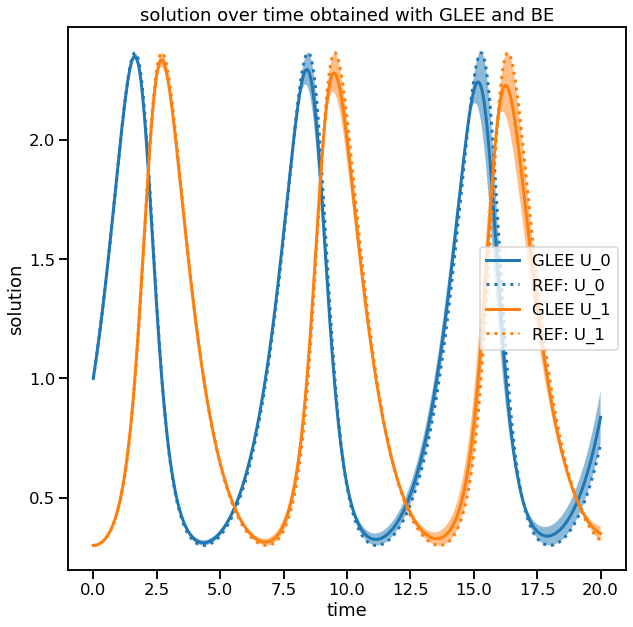

In [24]:
fig = plt.figure(figsize=(10, 10))
for i in range(u_glee.shape[0]):
    h=plt.plot(t,u_glee[i,:],'-', lw=3, label = 'GLEE U_{:}'.format(i))
    col=h[0].get_color()
    h=plt.plot(t,u_ref[i,:],':', lw=3,color=col, label = 'REF: U_{:}'.format(i))
    std=glee[i,:]
    plt.fill_between(t, u_glee[i,:]-std, u_glee[i,:]+std,
                     facecolor=col,      # The fill color
                     #color='black',      # The outline color
                     alpha=0.5)          # Transparency of the fill

plt.ylabel('solution')
plt.xlabel('time')
plt.legend()
plt.title('solution over time obtained with GLEE and BE')
plt.show()

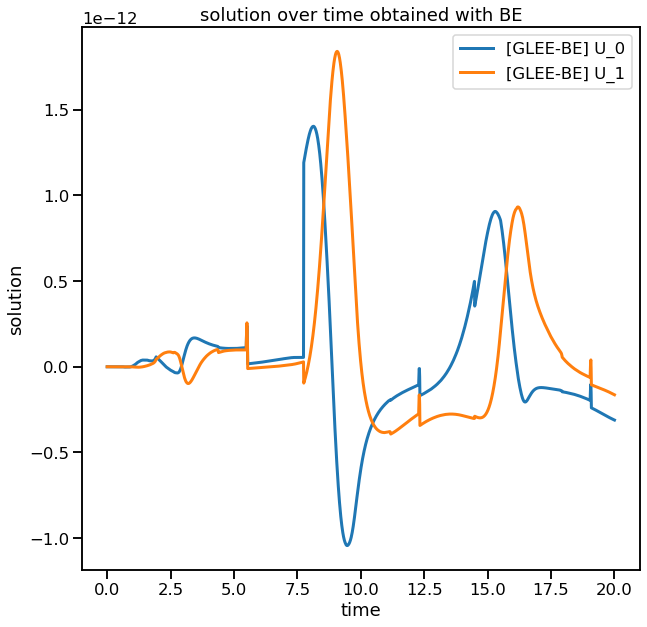

In [15]:
fig = plt.figure(figsize=(10, 10))
for i in range(u_glee.shape[0]):
    h=plt.plot(t,u_glee[i,:]-u_be[i,:],'-', lw=3, label = '[GLEE-BE] U_{:}'.format(i))
plt.ylabel('solution')
plt.xlabel('time')
plt.legend()
plt.title('Difference between solutions   solved  by GLEE and BE')
plt.show()